In [1]:
import firedrake as fd

In [2]:
import matplotlib.pyplot as plt
from typing import Any

In [ ]:
cm = fd.tripcolor(u)
plt.colorbar(cm)

In [26]:
mesh = UnitSquareMesh(50,50, diagonal="crossed")

degree = 1
Q = fd.FunctionSpace(mesh, "RT", degree+1)
V = fd.FunctionSpace(mesh, "DG", degree)

Z = fd.MixedFunctionSpace([V,Q])
z = fd.Function(Z)
u,psi = fd.split(z)

u_old = fd.Function(V) 
psi_old = fd.Function(Q)

z_trial = fd.TestFunction(Z)
v,w = fd.split(z_trial)

alpha = fd.Constant(1)

# See (5.5a) and (5.5b) in https://doi.org/10.1016/j.cma.2025.118181.
F = fd.inner(psi / fd.sqrt(1+fd.dot(psi,psi)), w)*fd.dx(degree=4) + fd.inner(u, fd.div(w))*fd.dx
F += fd.inner(fd.div(psi), v)*fd.dx - fd.inner(fd.div(psi_old), v)*fd.dx + alpha*fd.inner(fd.Constant(1), v)*fd.dx


def build_indicator_submesh(
    mesh: Any,
    dq0: FunctionSpace,
    indicator_expr: Any,
    marker: int,
) -> Any:
    """Construct a submesh from a DG indicator-based cell selection."""
    indicator = Function(dq0).interpolate(
        conditional(indicator_expr, 1, 0)
    )
    mesh.mark_entities(indicator, marker)
    return Submesh(mesh, 2, marker)

def extract_interface_markers(
    parent_mesh: Any,
    child_mesh: Any,
) -> tuple[int, ...]:
    """Return child-submesh facet markers not located on the parent exterior.

    The returned set identifies candidate parent/child interface markers
    used in the coupling constraints.
    """
    parent_exterior = {
        int(marker)
        for marker in parent_mesh.exterior_facets.unique_markers
    }
    child_exterior = {
        int(marker)
        for marker in child_mesh.exterior_facets.unique_markers
    }
    return tuple(sorted(child_exterior - parent_exterior))


center_marker = 999999
x, y = SpatialCoordinate(mesh)
dg0 = FunctionSpace(mesh, "DG", 0)
center = build_indicator_submesh(mesh, dg0, sqrt((x - 0.5) ** 2 + (y - 0.5) ** 2) < 0.1, center_marker)
interface_markers = extract_interface_markers(mesh, center)
bcs =  DirichletBC(Z.sub(0), 0, [center_marker])


# Use LU factorization
tol = 1e-4
sp = {"snes_type": "newtonls",
    "snes_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
    "snes_rtol": tol,
    "snes_atol": tol,
    "snes_stol": tol,
}

NLVP = NonlinearVariationalProblem(F, z, bcs=bcs)
NLVS = NonlinearVariationalSolver(NLVP, solver_parameters=sp)

u, psi = z.subfunctions
out = VTKFile("out/eikonal.pvd")
alpha.assign(1)

lvpp_max_its = 40 # max LVPP iterates
for k in range(lvpp_max_its):
    print(f"alpha = {float(alpha)}")
    u_old.assign(u)

    NLVS.solve() # solve the LVPP subproblem
    psi_old.assign(psi) # update the previous latent variable

    out.write(u) # save current iterate to disk
    
    # break if ||u^k - u^{k-1}||_{L^2} <= 1e-4
    nrm = norm(u-u_old, "L2")
    print("LVPP it: %s, Cauchy Error: %s\n"%(k,nrm))
    if nrm < 1e-4:
        break

    # update rule for proximal parameter alpha
    if float(alpha) < 150:
        alpha.assign(sqrt(2)*alpha)

alpha = 1.0


LookupError: BC construction got invalid markers {999999}. Valid markers are '{np.int32(1), np.int32(2), np.int32(3), np.int32(4)}'

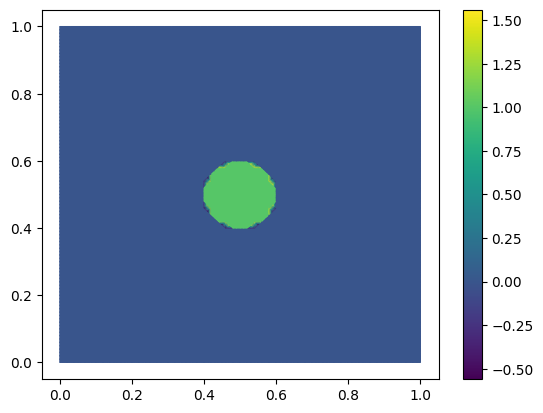

In [20]:
cm = firedrake.tripcolor(assemble(Function(V).interpolate(sqrt((x - 0.5) ** 2 + (y - 0.5) ** 2) < 0.1)))
plt.colorbar(cm)

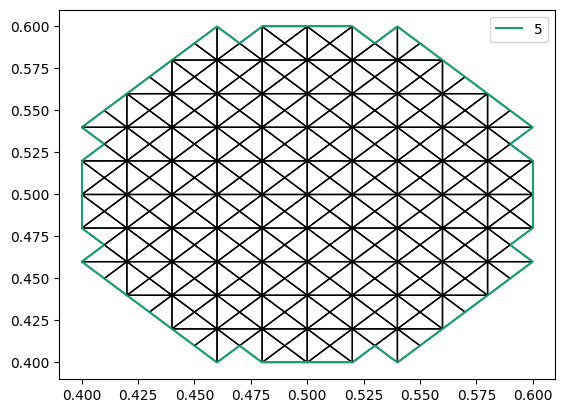

In [22]:
firedrake.triplot(center)
plt.legend()

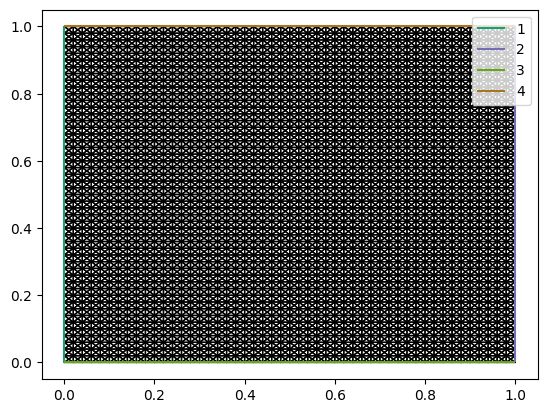

In [23]:
firedrake.triplot(mesh)
plt.legend()